<a href="https://colab.research.google.com/github/azrapatvi/nlp_practice/blob/main/14_resume_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [82]:
import os

df=pd.read_csv(os.path.join(path,'Resume/Resume.csv'))

In [83]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [84]:
df['Resume_str'][0]

"         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss pr

In [85]:
df['Resume_str'][1]

"         HR SPECIALIST, US HR OPERATIONS       Summary     Versatile  media professional with background in Communications, Marketing, Human Resources and Technology.\xa0        Experience     09/2015   to   Current     HR Specialist, US HR Operations    Company Name   －   City  ,   State       Managed communication regarding launch of Operations group, policy changes and system outages      Designed standard work and job aids to create comprehensive training program for new employees and contractors         Audited job postings for old, pending, on-hold and draft positions.           Audited union hourly, non-union hourly and salary background checks and drug screens             Conducted monthly new hire benefits briefing to new employees across all business units               Served as a link between HR Managers and vendors by handling questions and resolving system-related issues         Provide real-time process improvement feedback on key metrics and initiatives  Successfully r

In [86]:
df.columns=df.columns.str.lower()

In [87]:
df.head()

,id,resume_str,resume_html,category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [88]:
df.shape

(2484, 4)

In [89]:
df['resume_html'][0]

'<div class="fontsize fontface vmargins hmargins linespacing pagesize" id="document"> <div class="section firstsection" id="SECTION_NAME500375979" style="\n      padding-top:0px;\n    "> <div class="paragraph PARAGRAPH_NAME firstparagraph" id="PARAGRAPH_500375979_1_326506904" style="\n      padding-top:0px;\n    "> <div class="name" itemprop="name"> <span class="field fName" id="500375979FNAM1"> </span> <span> </span> <span class="field" id="500375979LNAM1"> HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR</span> </div> </div> </div> <div class="section" id="SECTION_SUMM500375981" style="\n      padding-top:0px;\n    "> <div class="heading bottomborder"> <div class="sectiontitle" id="SECTNAME_SUMM500375981"> Summary</div> </div> <div class="paragraph firstparagraph" id="PARAGRAPH_500375981_1_326506917" style="\n      padding-top:0px;\n    "> <div class="field singlecolumn" id="500375981FRFM1"> <p align="LEFT"> Dedicated Customer Service Manager with 15+ years of experience in H

In [90]:
df.isnull().sum()

,0
id,0
resume_str,0
resume_html,0
category,0


In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df.drop(['id','resume_html'],axis=1,inplace=True)

In [93]:
df.head(2)

,resume_str,category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR


In [94]:
df.duplicated().sum()

np.int64(2)

In [95]:
df.drop_duplicates(inplace=True)

In [96]:
df.head()

,resume_str,category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [97]:
df['category']

,category
0,HR
1,HR
2,HR
3,HR
4,HR
...,...
2478,AVIATION
2479,AVIATION
2480,AVIATION
2481,AVIATION


In [98]:
df['category'].value_counts()

,count
category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,117
FITNESS,117
SALES,116


category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   117
FITNESS                   117
SALES                     116
AVIATION                  116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64



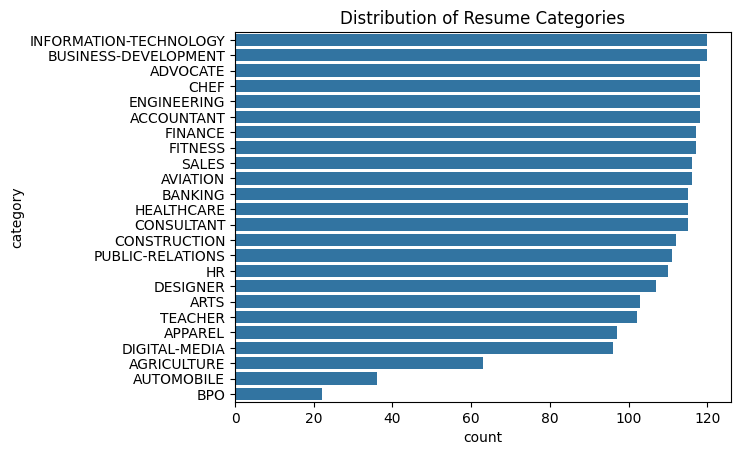

In [99]:
print(df['category'].value_counts())
print()

sns.countplot(df['category'],order=df['category'].value_counts().index)
plt.title("Distribution of Resume Categories")
plt.show()

In [100]:
# splitting the data

X=df['resume_str']
y=df['category']

In [101]:
df['category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

In [102]:
y

,category
0,HR
1,HR
2,HR
3,HR
4,HR
...,...
2478,AVIATION
2479,AVIATION
2480,AVIATION
2481,AVIATION


In [103]:
#train test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [104]:
X_train

,resume_str
2076,ASSOCIATE VICE PRESIDENT FOR COLLEGE ...
1857,ACCOUNTANT Summary Flexible ...
1482,FINANCE DIRECTOR Summary ...
836,OPERATIONS MANAGER Skills ...
182,LEAD INTERACTION DESIGNER Summa...
...,...
1464,ADMINISTRATIVE ASSISTANT Care...
1345,ADJUSTER Experience Ad...
1305,DIGITAL MARKETING ASSOCIATE Sum...
1675,CFO ASSISTANT/EXECUTIVE ADMINISTRATOR...


In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()



In [106]:
X_train=tfidf.fit_transform(X_train)
X_test=tfidf.transform(X_test)

In [107]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 713132 stored elements and shape (1985, 36090)>

In [108]:
#model training

from sklearn.naive_bayes import MultinomialNB

model=MultinomialNB()

In [109]:
model

MultinomialNB()

In [110]:
model.fit(X_train,y_train)

MultinomialNB()

In [111]:
y_pred=model.predict(X_test)

y_pred

array(['DIGITAL-MEDIA', 'HR', 'BUSINESS-DEVELOPMENT',
       'BUSINESS-DEVELOPMENT', 'ADVOCATE', 'TEACHER', 'CONSTRUCTION',
       'FINANCE', 'AVIATION', 'BUSINESS-DEVELOPMENT', 'HR',
       'INFORMATION-TECHNOLOGY', 'INFORMATION-TECHNOLOGY', 'CONSTRUCTION',
       'ADVOCATE', 'DESIGNER', 'ENGINEERING', 'ENGINEERING',
       'INFORMATION-TECHNOLOGY', 'FITNESS', 'HR',
       'INFORMATION-TECHNOLOGY', 'CONSTRUCTION', 'SALES', 'HR',
       'DESIGNER', 'FITNESS', 'ENGINEERING', 'BUSINESS-DEVELOPMENT', 'HR',
       'ADVOCATE', 'FITNESS', 'DESIGNER', 'INFORMATION-TECHNOLOGY',
       'FITNESS', 'ACCOUNTANT', 'PUBLIC-RELATIONS', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'BUSINESS-DEVELOPMENT', 'HR', 'ACCOUNTANT',
       'SALES', 'CHEF', 'CONSTRUCTION', 'BUSINESS-DEVELOPMENT',
       'ACCOUNTANT', 'ACCOUNTANT', 'FINANCE', 'BUSINESS-DEVELOPMENT',
       'TEACHER', 'HEALTHCARE', 'ACCOUNTANT', 'SALES', 'FITNESS',
       'BUSINESS-DEVELOPMENT', 'ADVOCATE', 'PUBLIC-RELATIONS',
       'CONSTRUCTION'

In [113]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5211267605633803
                        precision    recall  f1-score   support

            ACCOUNTANT       0.45      0.88      0.59        24
              ADVOCATE       0.29      0.50      0.36        24
           AGRICULTURE       0.00      0.00      0.00        13
               APPAREL       1.00      0.05      0.10        19
                  ARTS       1.00      0.14      0.25        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.81      0.57      0.67        23
               BANKING       0.93      0.61      0.74        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.29      0.92      0.44        24
                  CHEF       0.77      0.71      0.74        24
          CONSTRUCTION       0.62      0.59      0.60        22
            CONSULTANT       0.00      0.00      0.00        23
              DESIGNER       0.75      0.43      0.55        21
         D

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [114]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights=compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [115]:
model = MultinomialNB()
model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

MultinomialNB()

In [116]:
y_pred = model.predict(X_test)

In [117]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5694164989939637
                        precision    recall  f1-score   support

            ACCOUNTANT       0.46      0.88      0.60        24
              ADVOCATE       0.32      0.33      0.33        24
           AGRICULTURE       1.00      0.31      0.47        13
               APPAREL       0.50      0.16      0.24        19
                  ARTS       0.50      0.14      0.22        21
            AUTOMOBILE       1.00      0.57      0.73         7
              AVIATION       0.81      0.57      0.67        23
               BANKING       0.93      0.61      0.74        23
                   BPO       1.00      0.25      0.40         4
  BUSINESS-DEVELOPMENT       0.41      0.83      0.55        24
                  CHEF       0.81      0.71      0.76        24
          CONSTRUCTION       0.62      0.73      0.67        22
            CONSULTANT       1.00      0.09      0.16        23
              DESIGNER       0.85      0.52      0.65        21
         D

In [118]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression OvR": LogisticRegression(
        multi_class="ovr"
    ),

    "Logistic Regression Multinomial": LogisticRegression(
        multi_class="multinomial"
    ),

    "Linear SVM": LinearSVC(),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    )
}

In [119]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print()

Naive Bayes
Accuracy: 0.5211267605633803



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression OvR
Accuracy: 0.6237424547283702



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Multinomial
Accuracy: 0.6317907444668008

Linear SVM
Accuracy: 0.6981891348088531

KNN
Accuracy: 0.48088531187122735

Decision Tree
Accuracy: 0.5553319919517102

Random Forest
Accuracy: 0.6317907444668008



In [120]:
models = {
    "Logistic Regression": LogisticRegression(),

    "Linear SVM": LinearSVC(),

    "Random Forest": RandomForestClassifier()
}

In [121]:
params = {
    "Logistic Regression": {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "newton-cg"],
        "multi_class": ["multinomial"]
    },

    "Linear SVM": {
        "C": [0.1, 1, 10]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    }
}

In [124]:

from sklearn.model_selection import GridSearchCV
best_models = {}

for name in models:

    print("Tuning:", name)

    grid = GridSearchCV(
        estimator=models[name],
        param_grid=params[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    print("Best Parameters:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    print()

Tuning: Logistic Regression


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Parameters: {'C': 10, 'multi_class': 'multinomial', 'solver': 'lbfgs'}
Best CV Score: 0.6654911838790932

Tuning: Linear SVM
Best Parameters: {'C': 1}
Best CV Score: 0.6806045340050377

Tuning: Random Forest
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score: 0.6448362720403022



In [125]:
from sklearn.metrics import accuracy_score

for name, model in best_models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(name)
    print("Test Accuracy:", accuracy)
    print()

Logistic Regression
Test Accuracy: 0.6680080482897385

Linear SVM
Test Accuracy: 0.6981891348088531

Random Forest
Test Accuracy: 0.647887323943662



In [126]:
model=LinearSVC(C=1)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.6981891348088531


In [131]:
import joblib

joblib.dump(model,'model.pkl')

['model.pkl']

In [132]:
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

In [133]:
import os
os.listdir()

['.config', 'tfidf.pkl', 'model.pkl', 'sample_data']

In [134]:
from google.colab import files

files.download("model.pkl")
files.download("tfidf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [112]:
df.head(2)

,resume_str,category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
